Jason Stys

In [ ]:
# Cell 1
# Load dependencies

import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, SpatialDropout1D, SimpleRNN
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# Cell 2
# Set hyperparameters for the BASE model

output_dir = 'model_output/rnn_base'

# training:
epochs = 16
batch_size = 128

# vector space embedding:
n_dim = 64
n_unique_words = 10000
max_review_length = 100
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# RNN layer architecture:
n_rnn = 256
drop_rnn = 0.2

In [ ]:
# Cell 3
# Load and preprocess data

(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words)

x_train = pad_sequences(
    x_train,
    maxlen=max_review_length,
    padding=pad_type,
    truncating=trunc_type,
    value=0
)

x_valid = pad_sequences(
    x_valid,
    maxlen=max_review_length,
    padding=pad_type,
    truncating=trunc_type,
    value=0
)

print('x_train shape:', x_train.shape)
print('x_valid shape:', x_valid.shape)
print('y_train shape:', y_train.shape)
print('y_valid shape:', y_valid.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (25000, 100)
x_valid shape: (25000, 100)
y_train shape: (25000,)
y_valid shape: (25000,)


In [ ]:
# Cell 4
# Design neural network architecture for the BASE model

base_model = Sequential()

# 1st hidden layer
base_model.add(
    Embedding(
        input_dim=n_unique_words,
        output_dim=n_dim,
        input_shape=(max_review_length,)
    )
)

base_model.add(SpatialDropout1D(drop_embed))

# 2nd hidden layer
base_model.add(SimpleRNN(n_rnn, dropout=drop_rnn))

# output layer
base_model.add(Dense(1, activation='sigmoid'))

base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 256)            │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,433 (2.76 MB)

 Trainable params: 722,433 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 5
# Configure and train the BASE model

base_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

base_checkpoint = ModelCheckpoint(
    filepath=os.path.join(output_dir, 'best_base.keras'),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

base_history = base_model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[base_checkpoint]
)

Epoch 1/16
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5089 - loss: 0.6986
Epoch 1: val_accuracy improved from None to 0.50000, saving model to model_output/rnn_base/best_base.keras

Epoch 1: finished saving model to model_output/rnn_base/best_base.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5140 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.7004
Epoch 2/16
191/196 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5598 - loss: 0.6740
Epoch 2: val_accuracy improved from 0.50000 to 0.58096, saving model to model_output/rnn_base/best_base.keras

Epoch 2: finished saving model to model_output/rnn_base/best_base.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5902 - loss: 0.6574 - val_accuracy: 0.5810 - val_loss: 0.6718
Epoch 3/16
193/196 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6857 - loss: 0.5826
Epoch 3: val_accuracy improved from 0.58096 to 0.63696, saving model to model_output/rnn_base/best_base.keras

Epoch 3: finished saving model

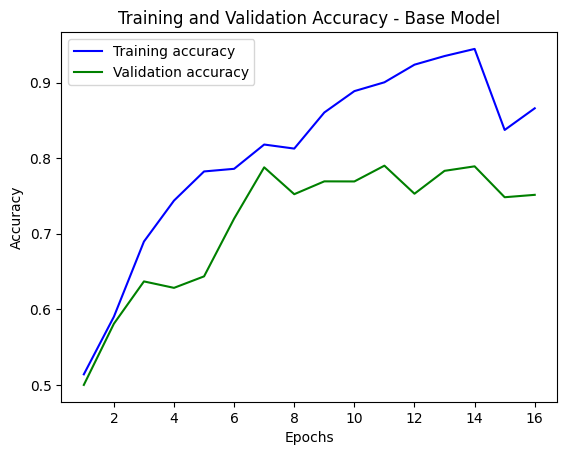

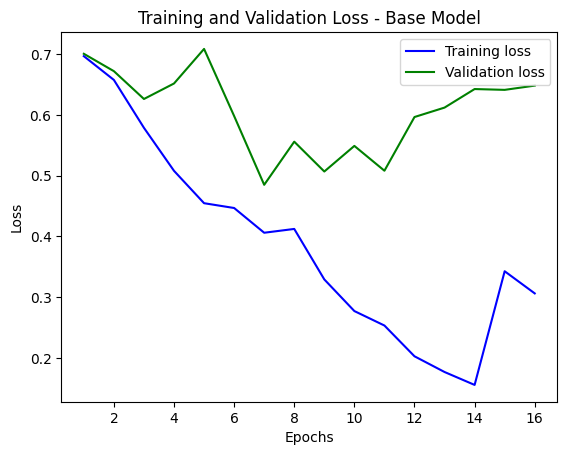

Baseline best validation accuracy: 0.7901
Baseline best epoch: 11


In [ ]:
# Cell 6
# Evaluate the BASE model

acc_train = base_history.history['accuracy']
acc_val = base_history.history['val_accuracy']
loss_train = base_history.history['loss']
loss_val = base_history.history['val_loss']
epochs_range = range(1, len(acc_train) + 1)

plt.plot(epochs_range, acc_train, 'b', label='Training accuracy')
plt.plot(epochs_range, acc_val, 'g', label='Validation accuracy')
plt.title('Training and Validation Accuracy - Base Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs_range, loss_train, 'b', label='Training loss')
plt.plot(epochs_range, loss_val, 'g', label='Validation loss')
plt.title('Training and Validation Loss - Base Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

best_base_epoch = acc_val.index(max(acc_val)) + 1
best_base_acc = max(acc_val)

print(f'Baseline best validation accuracy: {best_base_acc:.4f}')
print(f'Baseline best epoch: {best_base_epoch}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


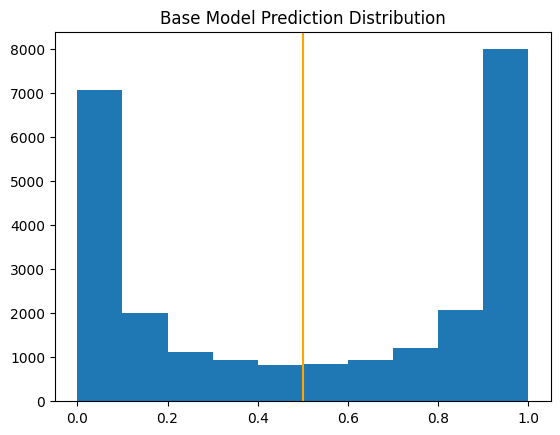

Base ROC AUC: 86.63


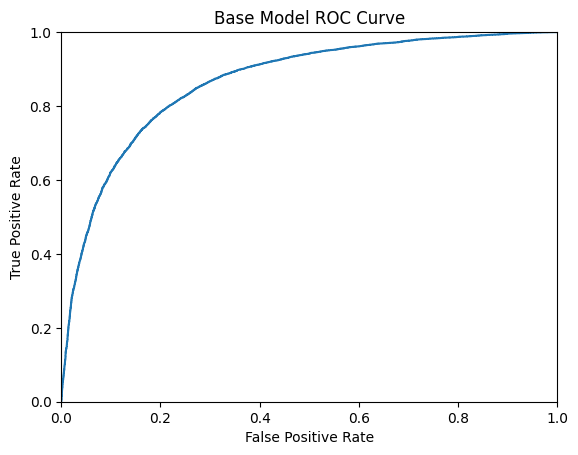

In [ ]:
# Cell 7
# ROC AUC evaluation for the BASE model

base_model.load_weights(os.path.join(output_dir, 'best_base.keras'))

y_hat_base = base_model.predict(x_valid)

plt.hist(y_hat_base)
_ = plt.axvline(x=0.5, color='orange')
plt.title('Base Model Prediction Distribution')
plt.show()

print('Base ROC AUC:', "{:.2f}".format(roc_auc_score(y_valid, y_hat_base) * 100.0))

fpr, tpr, thresholds = roc_curve(y_valid, y_hat_base)
plt.plot(fpr, tpr)
plt.axis([0, 1, 0, 1])
plt.title('Base Model ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
# Cell 8
# Set hyperparameters for the IMPROVED model
# These changes keep the same dataset and SimpleRNN style,
# but tune the model to try to improve validation accuracy.

output_dir_improved = 'model_output/rnn_improved'

# training:
epochs_improved = 20
batch_size_improved = 64

# vector space embedding:
n_dim_improved = 128
n_unique_words_improved = 10000
max_review_length_improved = 100
pad_type_improved = trunc_type_improved = 'pre'
drop_embed_improved = 0.3

# RNN layer architecture:
n_rnn_improved = 128
drop_rnn_improved = 0.3
learning_rate_improved = 0.0005

In [ ]:
# Cell 9
# Build, configure, and train the IMPROVED model

improved_model = Sequential()

improved_model.add(
    Embedding(
        input_dim=n_unique_words_improved,
        output_dim=n_dim_improved,
        input_shape=(max_review_length_improved,)
    )
)

improved_model.add(SpatialDropout1D(drop_embed_improved))
improved_model.add(
    SimpleRNN(
        n_rnn_improved,
        dropout=drop_rnn_improved,
        recurrent_dropout=0.2
    )
)
improved_model.add(Dense(1, activation='sigmoid'))

improved_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=learning_rate_improved),
    metrics=['accuracy']
)

if not os.path.exists(output_dir_improved):
    os.makedirs(output_dir_improved)

improved_checkpoint = ModelCheckpoint(
    filepath=os.path.join(output_dir_improved, 'best_improved.keras'),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

improved_history = improved_model.fit(
    x_train,
    y_train,
    batch_size=batch_size_improved,
    epochs=epochs_improved,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[improved_checkpoint, early_stop, reduce_lr]
)

improved_model.summary()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5144 - loss: 0.7102
Epoch 1: val_accuracy improved from None to 0.52728, saving model to model_output/rnn_improved/best_improved.keras

Epoch 1: finished saving model to model_output/rnn_improved/best_improved.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.5166 - loss: 0.7032 - val_accuracy: 0.5273 - val_loss: 0.6856 - learning_rate: 5.0000e-04
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 0.6837
Epoch 2: val_accuracy improved from 0.52728 to 0.57840, saving model to model_output/rnn_improved/best_improved.keras

Epoch 2: finished saving model to model_output/rnn_improved/best_improved.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5538 - loss: 0.6803 - val_accuracy: 0.5784 - val_loss: 0.6691 - learning_rate: 5.0000e-04
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5938 - loss: 0.6641
Epoch 3: val_accuracy improved from 0.57840 to 0.61468, saving m

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,939,077 (15.03 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,626,052 (10.02 MB)

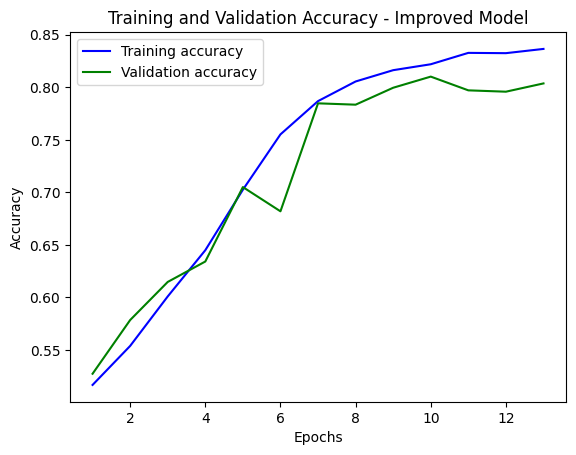

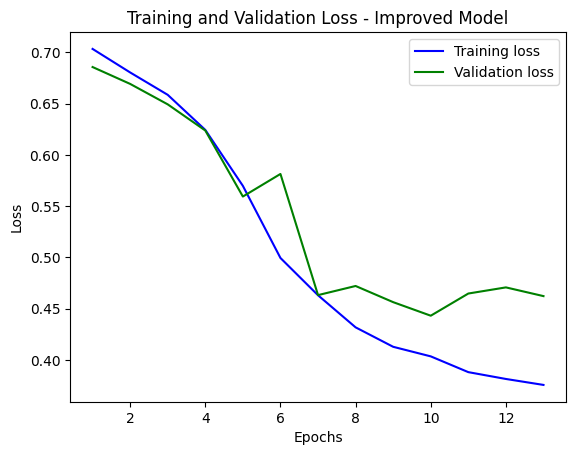

Improved best validation accuracy: 0.8102
Improved best epoch: 10

Comparison
Base model best val accuracy:     0.7901 at epoch 11
Improved model best val accuracy: 0.8102 at epoch 10
Improvement: 0.0200


In [ ]:
# Cell 10
# Evaluate the IMPROVED model and compare it to the BASE model

acc_train_improved = improved_history.history['accuracy']
acc_val_improved = improved_history.history['val_accuracy']
loss_train_improved = improved_history.history['loss']
loss_val_improved = improved_history.history['val_loss']
epochs_range_improved = range(1, len(acc_train_improved) + 1)

plt.plot(epochs_range_improved, acc_train_improved, 'b', label='Training accuracy')
plt.plot(epochs_range_improved, acc_val_improved, 'g', label='Validation accuracy')
plt.title('Training and Validation Accuracy - Improved Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs_range_improved, loss_train_improved, 'b', label='Training loss')
plt.plot(epochs_range_improved, loss_val_improved, 'g', label='Validation loss')
plt.title('Training and Validation Loss - Improved Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

best_improved_epoch = acc_val_improved.index(max(acc_val_improved)) + 1
best_improved_acc = max(acc_val_improved)

print(f'Improved best validation accuracy: {best_improved_acc:.4f}')
print(f'Improved best epoch: {best_improved_epoch}')

print()
print('Comparison')
print(f'Base model best val accuracy:     {best_base_acc:.4f} at epoch {best_base_epoch}')
print(f'Improved model best val accuracy: {best_improved_acc:.4f} at epoch {best_improved_epoch}')
print(f'Improvement: {best_improved_acc - best_base_acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


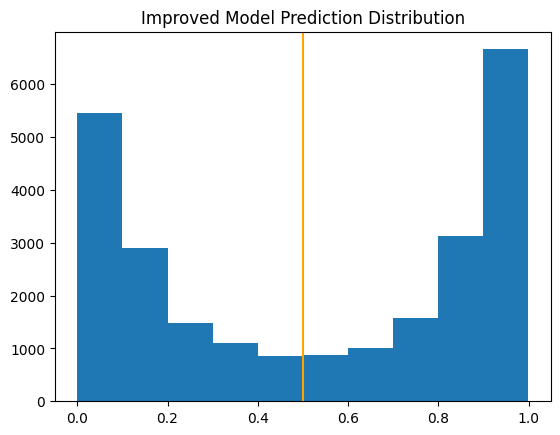

Improved ROC AUC: 88.32


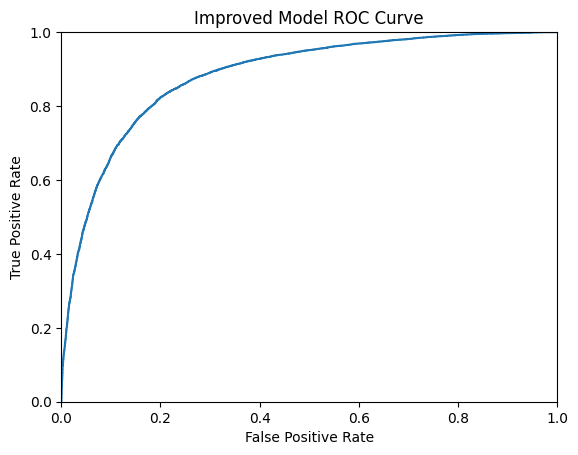

In [ ]:
# Cell 11
# ROC AUC evaluation for the IMPROVED model

improved_model.load_weights(os.path.join(output_dir_improved, 'best_improved.keras'))

y_hat_improved = improved_model.predict(x_valid)

plt.hist(y_hat_improved)
_ = plt.axvline(x=0.5, color='orange')
plt.title('Improved Model Prediction Distribution')
plt.show()

print('Improved ROC AUC:', "{:.2f}".format(roc_auc_score(y_valid, y_hat_improved) * 100.0))

fpr, tpr, thresholds = roc_curve(y_valid, y_hat_improved)
plt.plot(fpr, tpr)
plt.axis([0, 1, 0, 1])
plt.title('Improved Model ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()